In [ ]:
import csv
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
def load_training(path):
    with open(path, encoding="utf-8") as f:
        rows = list(csv.reader(f))
    texts = [r[0].strip() or r[3].strip() for r in rows]
    labels = [r[1].strip() for r in rows]
    return pd.DataFrame({"text": texts, "sentiment": labels})

LABEL_MAP = {"Negative": 0, "Positive": 1}
CLASS_NAMES = ["Negative", "Positive"]

def prep(df):
    df = df[df["sentiment"].isin(CLASS_NAMES)]
    df["label"] = df["sentiment"].map(LABEL_MAP)
    return df.reset_index(drop=True)


raw_train = load_training("/content/drive/MyDrive/twitter_training.csv")  # مسیر خودت رو جایگزین کن
print("unique sentiment values:", raw_train["sentiment"].unique())
print(raw_train.head())
print("raw row count:", len(raw_train))

train_df = prep(raw_train)
test_df = prep(pd.read_csv("/content/drive/MyDrive/twitter_validation.csv"))  # مسیر خودت رو جایگزین کن

print("train_df after prep:", len(train_df))

train_df, val_df = train_test_split(train_df, test_size=0.1, stratify=train_df["label"], random_state=42)

print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")

unique sentiment values: ['sentiment' 'Positive' 'Negative']
                                                text  sentiment
0                                               text  sentiment
1  im getting on borderlands and i will murder yo...   Positive
2  I am coming to the borders and I will kill you...   Positive
3  im getting on borderlands and i will kill you ...   Positive
4  im coming on borderlands and i will murder you...   Positive
raw row count: 39979


/tmp/ipykernel_620/823207699.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = df["sentiment"].map(LABEL_MAP)


train_df after prep: 39978
train=35980  val=3998  test=542


In [ ]:

import tensorflow as tf
SEQ_LEN, EMBED_DIM, NUM_HEADS, FF_DIM = 40, 128, 4, 128
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

vectorizer = tf.keras.layers.TextVectorization(max_tokens=20000, output_sequence_length=SEQ_LEN)
vectorizer.adapt(train_df["text"].values)
vocab_size = len(vectorizer.get_vocabulary())


class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, seq_len, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = tf.keras.layers.Embedding(vocab_size, embed_dim)
        self.pos_emb = tf.keras.layers.Embedding(seq_len, embed_dim)

    def call(self, x):
        positions = tf.range(tf.shape(x)[-1])
        return self.token_emb(x) + self.pos_emb(positions)


class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att = tf.keras.layers.MultiHeadAttention(num_heads, embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(dropout)
        self.drop2 = tf.keras.layers.Dropout(dropout)

    def call(self, x, training=False):
        x = self.norm1(x + self.drop1(self.att(x, x), training=training))
        return self.norm2(x + self.drop2(self.ffn(x), training=training))

In [ ]:
def build_scratch_transformer():
    inputs = tf.keras.Input(shape=(SEQ_LEN,))
    x = PositionalEmbedding(SEQ_LEN, vocab_size, EMBED_DIM)(inputs)
    x = TransformerEncoder(EMBED_DIM, NUM_HEADS, FF_DIM)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inputs, outputs, name="scratch_transformer")


def make_scratch_ds(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((df["text"].values, df["label"].values))
    if shuffle:
        ds = ds.shuffle(len(df), seed=42)
    return ds.batch(BATCH).map(lambda t, l: (vectorizer(t), l)).prefetch(AUTOTUNE)

scratch_model = build_scratch_transformer()
scratch_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
reduce = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss" ,patience=3 ,factor=0.5, min_lr=2e-5)
histories = {}
histories["Scratch-Transformer"] = scratch_model.fit(
    make_scratch_ds(train_df, shuffle=True),
    validation_data=make_scratch_ds(val_df),
    epochs=15, callbacks=[early],
)

Epoch 1/15
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 272s 237ms/step - accuracy: 0.7585 - loss: 0.5009 - val_accuracy: 0.8224 - val_loss: 0.4187
Epoch 2/15
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 253s 225ms/step - accuracy: 0.8649 - loss: 0.3483 - val_accuracy: 0.8339 - val_loss: 0.4147
Epoch 3/15
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 255s 226ms/step - accuracy: 0.8900 - loss: 0.2821 - val_accuracy: 0.8402 - val_loss: 0.4208
Epoch 4/15
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 253s 225ms/step - accuracy: 0.9000 - loss: 0.2450 - val_accuracy: 0.8422 - val_loss: 0.5085
Epoch 5/15
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 254s 226ms/step - accuracy: 0.9094 - loss: 0.2179 - val_accuracy: 0.8252 - val_loss: 0.5165


In [ ]:
pretrained_models = {
    "BERT-Base": {"name": "bert-base-uncased", "tokenizer": None, "model": None},
    "DistilBERT": {"name": "distilbert-base-uncased", "tokenizer": None, "model": None},
}

for name, m in pretrained_models.items():
    print(f"Loading {name}...")
    m["tokenizer"] = AutoTokenizer.from_pretrained(m["name"])
    m["model"] = AutoModelForSequenceClassification.from_pretrained(m["name"], num_labels=2)
    print(f"{name} loaded.")

Loading BERT-Base...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT loaded.


In [ ]:
def make_hf_ds(tokenizer, df):
    inputs = tokenizer(df["text"].tolist(), padding=True, truncation=True, return_tensors="pt", max_length=SEQ_LEN)
    labels = torch.tensor(df["label"].tolist())
    dataset = torch.utils.data.TensorDataset(inputs["input_ids"], inputs["attention_mask"], labels)
    return torch.utils.data.DataLoader(dataset, batch_size=BATCH)

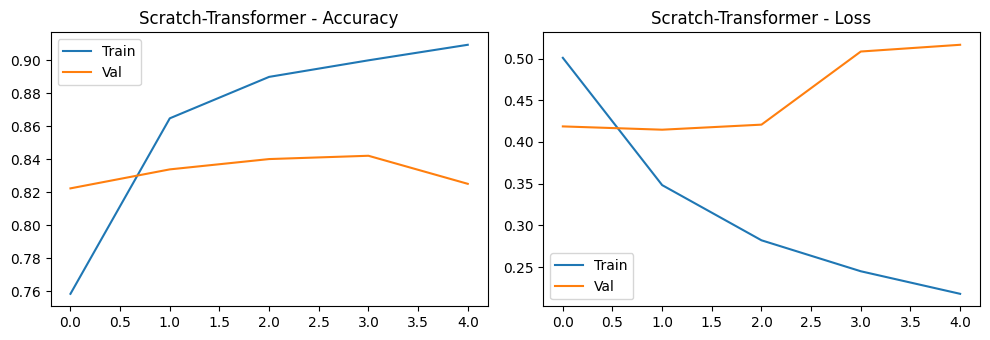

In [ ]:
for name, his in histories.items():
    plt.figure(figsize=(10, 3.5))
    plt.subplot(1, 2, 1); plt.plot(his.history["accuracy"]); plt.plot(his.history["val_accuracy"])
    plt.title(f"{name} - Accuracy"); plt.legend(["Train", "Val"])
    plt.subplot(1, 2, 2); plt.plot(his.history["loss"]); plt.plot(his.history["val_loss"])
    plt.title(f"{name} - Loss"); plt.legend(["Train", "Val"])
    plt.tight_layout(); plt.show()

In [ ]:
y_true = test_df["label"].values

def get_predictions():
    preds = {"Scratch-Transformer": (scratch_model.predict(make_scratch_ds(test_df)).ravel() > 0.5).astype(int)}
    for name, m in pretrained_models.items():
        m["model"].eval() # Set model to evaluation mode
        hf_preds_list = []
        with torch.no_grad(): # Disable gradient calculations for inference
            for batch_input_ids, batch_attention_mask, _ in make_hf_ds(m["tokenizer"], test_df):
                outputs = m["model"](input_ids=batch_input_ids, attention_mask=batch_attention_mask)
                hf_preds_list.append(outputs.logits)
        logits = torch.cat(hf_preds_list).cpu().numpy() # Concatenate all logits and move to CPU/Numpy
        preds[name] = np.argmax(logits, axis=1)
    return preds

def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="binary")
    rec = recall_score(y_true, y_pred, average="binary")
    print(f"\n=== {name} ===  Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}")
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))
    return acc

predictions = get_predictions()
accuracies = {name: evaluate(y_true, y_pred, name) for name, y_pred in predictions.items()}

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step

=== Scratch-Transformer ===  Accuracy: 0.9336  Precision: 0.9615  Recall: 0.9058
[[256  10]
 [ 26 250]]
              precision    recall  f1-score   support

    Negative       0.91      0.96      0.93       266
    Positive       0.96      0.91      0.93       276

    accuracy                           0.93       542
   macro avg       0.93      0.93      0.93       542
weighted avg       0.94      0.93      0.93       542


=== BERT-Base ===  Accuracy: 0.4908  Precision: 0.5000  Recall: 0.0507
[[252  14]
 [262  14]]
              precision    recall  f1-score   support

    Negative       0.49      0.95      0.65       266
    Positive       0.50      0.05      0.09       276

    accuracy                           0.49       542
   macro avg       0.50      0.50      0.37       542
weighted avg       0.50      0.49      0.36       542


=== DistilBERT ===  Accuracy: 0.4502  Precision: 0.4743  Recall: 0.7355
[[ 41 225]
 [ 73 203]]
          

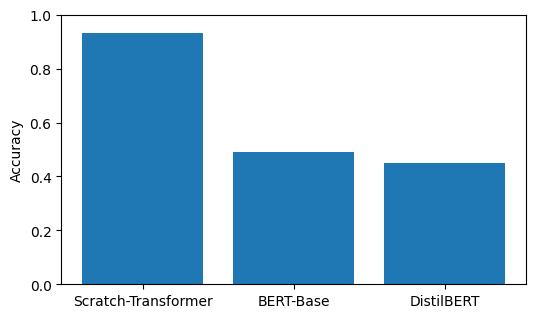

In [ ]:
plt.figure(figsize=(6, 3.5))
plt.bar(accuracies.keys(), accuracies.values())
plt.ylabel("Accuracy"); plt.ylim(0, 1)
plt.show()

In [ ]:
scratch_model.save("model_scratch_sentiment.keras")

In [ ]:
vectorizer.adapt(train_df["text"].values)
vocab_size = len(vectorizer.get_vocabulary())

import pickle
with open("vectorizer_vocab.pkl", "wb") as f:
    pickle.dump(vectorizer.get_vocabulary(), f)